## 📥 ETAP 0: Pozyskanie danych

**Cel:** przygotowanie surowych danych do analizy  

### Import bibliotek

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Biblioteki załadowane ✓")

Biblioteki załadowane ✓


### Wczytanie danuch

In [53]:
base_path = 'dane'

orders = pd.read_csv(f'{base_path}/olist_orders_dataset.csv')
order_items = pd.read_csv(f'{base_path}/olist_order_items_dataset.csv')
products = pd.read_csv(f'{base_path}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{base_path}/olist_sellers_dataset.csv')
customers = pd.read_csv(f'{base_path}/olist_customers_dataset.csv')
payments = pd.read_csv(f'{base_path}/olist_order_payments_dataset.csv')
reviews = pd.read_csv(f'{base_path}/olist_order_reviews_dataset.csv')
geolocation = pd.read_csv(f'{base_path}/olist_geolocation_dataset.csv')
category_translation = pd.read_csv(f'{base_path}/product_category_name_translation.csv')

print("=== Kształy danych ===")
for name, tabel in zip(
    ['orders', 'order_items', 'products', 'sellers', 'customers', 'payments', 'reviews', 'geolocation', 'category_translation'],
    [orders, order_items, products, sellers, customers, payments, reviews, geolocation, category_translation]
):
    print(f"{name}: {tabel.shape}")

=== Kształy danych ===
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
sellers: (3095, 4)
customers: (99441, 5)
payments: (103886, 5)
reviews: (99224, 7)
geolocation: (1000163, 5)
category_translation: (71, 2)


### Łącznie danych

In [54]:
payments_agg = payments.groupby('order_id').agg(
    payment_value_total=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
    payment_types_count=('payment_type', 'nunique'),
    payment_type_main=('payment_type', lambda x: x.mode().iloc[0])
).reset_index()

reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()

geo_dedup = geolocation.groupby('geolocation_zip_code_prefix').agg(
    customer_lat=('geolocation_lat', 'mean'),
    customer_lng=('geolocation_lng', 'mean')
).reset_index()

# ── Łączenie zgodnie ze schematem ERD ──
df = (
    order_items
    .merge(orders, on='order_id', how='left')                            # + daty, status, customer_id
    .merge(products, on='product_id', how='left')                        # + kategoria, wymiary
    .merge(category_translation, on='product_category_name', how='left') # + nazwa EN
    .merge(sellers, on='seller_id', how='left')                          # + lokalizacja sprzedawcy
    .merge(customers, on='customer_id', how='left')                      # + lokalizacja klienta
    .merge(payments_agg, on='order_id', how='left')                      # + płatności (zagregowane!)
    .merge(reviews_agg, on='order_id', how='left')                       # + oceny (zagregowane!)
    .merge(geo_dedup, left_on='customer_zip_code_prefix',                # + geolokalizacja (zdeduplikowana!)
           right_on='geolocation_zip_code_prefix', how='left')
)

print(f"Finalny DataFrame: {df.shape}")
print(f"Wierszy: {len(df):,} (powinno ≈ {len(order_items):,} = order_items)")
print("Kształt połączonego df:", df.shape)
print(df.head())

Finalny DataFrame: (112650, 39)
Wierszy: 112,650 (powinno ≈ 112,650 = order_items)
Kształt połączonego df: (112650, 39)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  \
0  2017-09-19 09:45:35   58.90          13.29   
1  2017-05-03 11:0

In [55]:

print("PODSUMOWANIE ŁĄCZENIA TABEL")

print(f"Finalny DataFrame: {df.shape}")
print(f"Kolumny ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nBraki danych (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

PODSUMOWANIE ŁĄCZENIA TABEL
Finalny DataFrame: (112650, 39)
Kolumny (39):
   1. order_id
   2. order_item_id
   3. product_id
   4. seller_id
   5. shipping_limit_date
   6. price
   7. freight_value
   8. customer_id
   9. order_status
  10. order_purchase_timestamp
  11. order_approved_at
  12. order_delivered_carrier_date
  13. order_delivered_customer_date
  14. order_estimated_delivery_date
  15. product_category_name
  16. product_name_lenght
  17. product_description_lenght
  18. product_photos_qty
  19. product_weight_g
  20. product_length_cm
  21. product_height_cm
  22. product_width_cm
  23. product_category_name_english
  24. seller_zip_code_prefix
  25. seller_city
  26. seller_state
  27. customer_unique_id
  28. customer_zip_code_prefix
  29. customer_city
  30. customer_state
  31. payment_value_total
  32. payment_installments_max
  33. payment_types_count
  34. payment_type_main
  35. review_score
  36. review_count
  37. geolocation_zip_code_prefix
  38. customer_la

## 🔎 ETAP 1: EDA (Exploratory Data Analysis)
🎯 Cel EDA

Masz odpowiedzieć:

jak wygląda sprzedaż w czasie
jakie są rozkłady
gdzie są problemy w danych
jakie wzorce można wykorzystać w modelu

In [56]:
# ── Podstawowe info ──
print("=== KSZTAŁT DANYCH ===")
print(f"Wierszy: {len(df):,}")
print(f"Kolumn: {df.shape[1]}")

print("\n=== BRAKI DANYCH ===")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\n=== TYPY DANYCH ===")
print(df.dtypes)

=== KSZTAŁT DANYCH ===
Wierszy: 112,650
Kolumn: 39

=== BRAKI DANYCH ===
order_delivered_customer_date    2454
product_category_name_english    1627
product_name_lenght              1603
product_category_name            1603
product_description_lenght       1603
product_photos_qty               1603
order_delivered_carrier_date     1194
review_score                      942
review_count                      942
geolocation_zip_code_prefix       302
dtype: int64

=== TYPY DANYCH ===
order_id                          object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_custo

### 🧹Data cleaning (OBOWIĄZKOWE)

In [57]:
# ── Konwersja dat ──
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("Daty skonwertowane ✓")


Daty skonwertowane ✓


In [58]:
# ---- Staus zamówień ----
status_counts = df['order_status'].value_counts(dropna=False)
status_share = (status_counts / len(df) * 100).round(2)
print("\n=== STATUS ZAMÓWIEŃ ===")
print(status_share)
print(f"\nUdział delivered: {status_share.get('delivered', 0):.1f}%")



=== STATUS ZAMÓWIEŃ ===
order_status
delivered      97.82
shipped         1.05
canceled        0.48
invoiced        0.32
processing      0.32
unavailable     0.01
approved        0.00
Name: count, dtype: float64

Udział delivered: 97.8%


In [59]:
# ── Filtrowanie do delivered ──
# Filtrujemy TYLKO po statusie delivered

delivered_df = df[df['order_status'] == 'delivered'].copy()

print(f"Wszystkie rekordy: {len(df):,}")
print(f"Delivered: {len(delivered_df):,}")
print(f"Udział: {len(delivered_df)/len(df)*100:.1f}%")
print(f"\nZakres dat:")
print(f"  Od: {delivered_df['order_purchase_timestamp'].min()}")
print(f"  Do: {delivered_df['order_purchase_timestamp'].max()}")

Wszystkie rekordy: 112,650
Delivered: 110,197
Udział: 97.8%

Zakres dat:
  Od: 2016-09-15 12:16:38
  Do: 2018-08-29 15:00:37


In [60]:
# ── Cechy dostawy ──
delivered_df['delivery_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']
).dt.days

delivered_df['delivery_vs_estimate_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_estimated_delivery_date']
).dt.days

print("Czas dostawy (dni):")
print(delivered_df['delivery_days'].describe().round(1))
print(f"\nDostawa vs estymata (dni):")
print(delivered_df['delivery_vs_estimate_days'].describe().round(1))


Czas dostawy (dni):
count    110189.0
mean         12.0
std           9.5
min           0.0
25%           6.0
50%          10.0
75%          15.0
max         209.0
Name: delivery_days, dtype: float64

Dostawa vs estymata (dni):
count    110189.0
mean        -12.0
std          10.2
min        -147.0
25%         -17.0
50%         -13.0
75%          -7.0
max         188.0
Name: delivery_vs_estimate_days, dtype: float64


In [61]:
# ── Podstawowe statystyki ──
print("=== PODSUMOWANIE DANYCH ===")
print(f"Unikalne zamówienia: {delivered_df['order_id'].nunique():,}")
print(f"Unikalne produkty: {delivered_df['product_id'].nunique():,}")
print(f"Unikalne kategorie: {delivered_df['product_category_name_english'].nunique()}")
print(f"Unikalni klienci: {delivered_df['customer_unique_id'].nunique():,}")
print(f"Unikalni sprzedawcy: {delivered_df['seller_id'].nunique():,}")
print(f"Łączny przychód: {delivered_df['price'].sum():,.2f}")
print(f"Średnia cena: {delivered_df['price'].mean():.2f}")
print(f"Średni koszt dostawy: {delivered_df['freight_value'].mean():.2f}")
print(f"Średni czas dostawy: {delivered_df['delivery_days'].mean():.1f} dni")
print(f"Średnia ocena: {delivered_df['review_score'].mean():.2f}")
print(f"\nBraki w kategorii: {delivered_df['product_category_name_english'].isnull().sum()}")

=== PODSUMOWANIE DANYCH ===
Unikalne zamówienia: 96,478
Unikalne produkty: 32,216
Unikalne kategorie: 71
Unikalni klienci: 93,358
Unikalni sprzedawcy: 2,970
Łączny przychód: 13,221,498.11
Średnia cena: 119.98
Średni koszt dostawy: 19.95
Średni czas dostawy: 12.0 dni
Średnia ocena: 4.08

Braki w kategorii: 1559


### Wizulizacja EDA

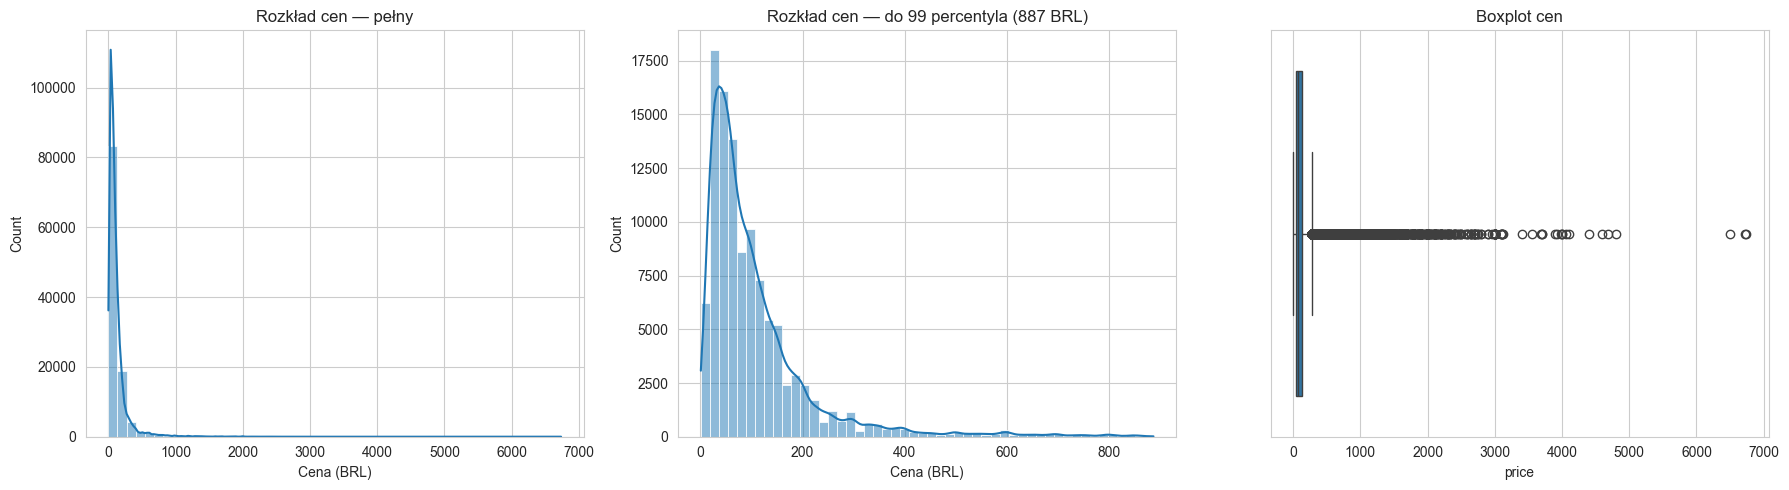

In [62]:
#---- Rozkład cen ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(delivered_df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Rozkład cen — pełny')
axes[0].set_xlabel('Cena (BRL)')

price_99 = delivered_df['price'].quantile(0.99)
sns.histplot(delivered_df[delivered_df['price'] <= price_99]['price'], bins=50, kde=True, ax=axes[1])
axes[1].set_title(f'Rozkład cen — do 99 percentyla ({price_99:.0f} BRL)')
axes[1].set_xlabel('Cena (BRL)')

sns.boxplot(x=delivered_df['price'], ax=axes[2])
axes[2].set_title('Boxplot cen')

plt.tight_layout()
plt.show()



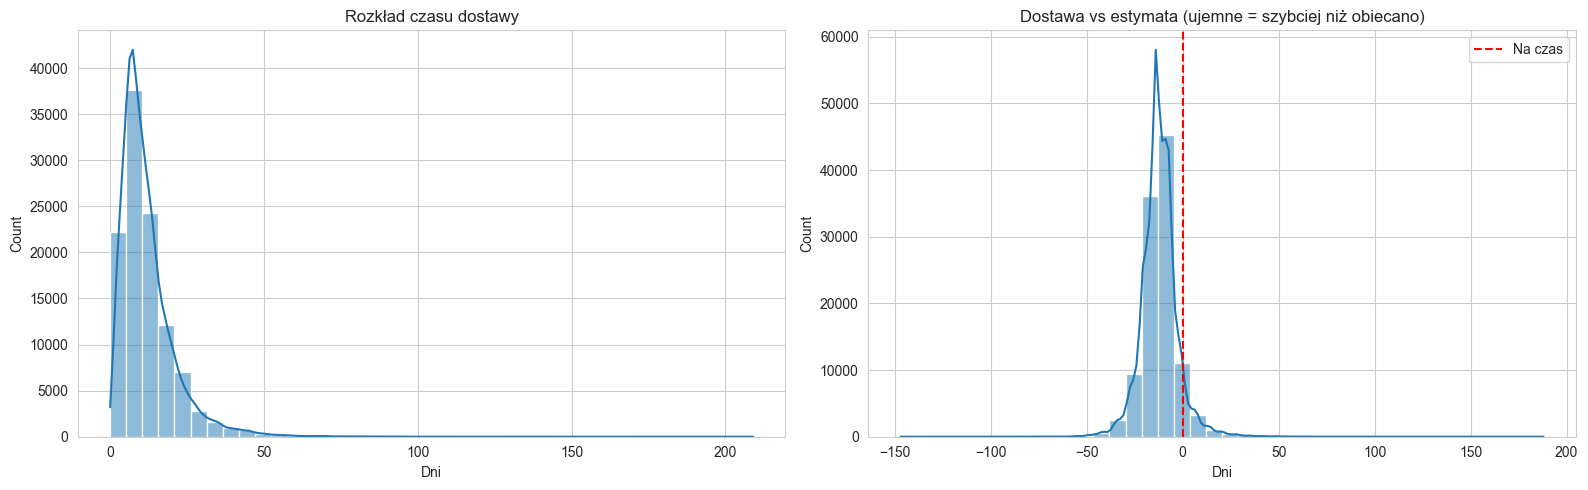

In [63]:
# ── Rozkład dostawy ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(delivered_df['delivery_days'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('Rozkład czasu dostawy')
axes[0].set_xlabel('Dni')

sns.histplot(delivered_df['delivery_vs_estimate_days'].dropna(), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Dostawa vs estymata (ujemne = szybciej niż obiecano)')
axes[1].set_xlabel('Dni')
axes[1].axvline(0, color='red', linestyle='--', label='Na czas')
axes[1].legend()

plt.tight_layout()
plt.show()


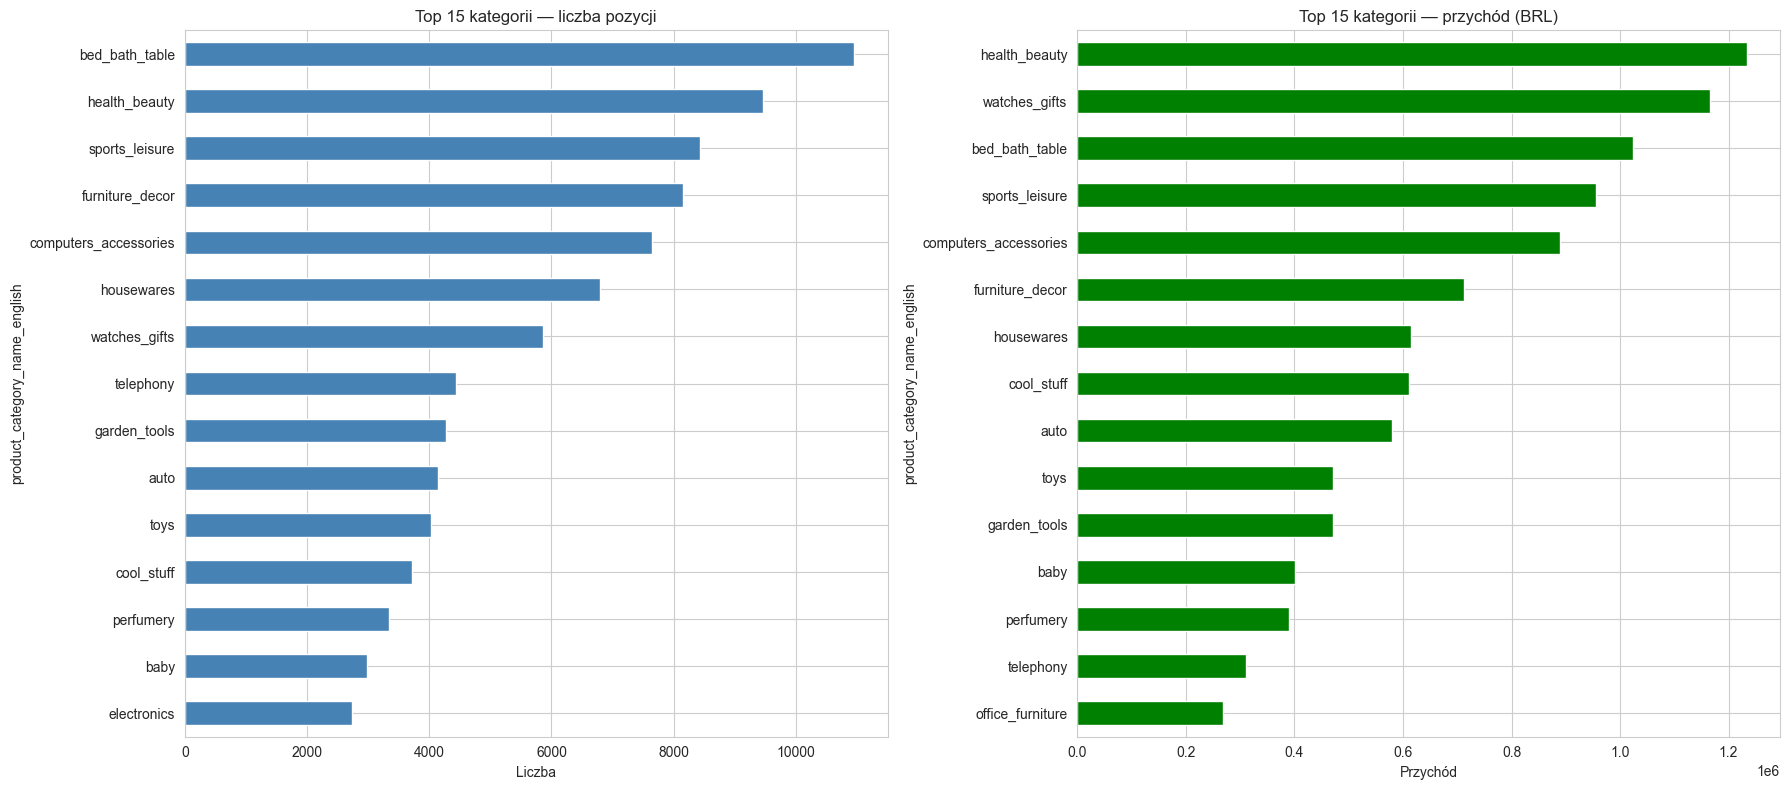

In [64]:
# ── Top 15 kategorii ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_count = delivered_df['product_category_name_english'].value_counts().head(15).sort_values()
top_count.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 kategorii — liczba pozycji')
axes[0].set_xlabel('Liczba')

top_revenue = (
    delivered_df.groupby('product_category_name_english')['price']
    .sum().sort_values(ascending=False).head(15).sort_values()
)
top_revenue.plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title('Top 15 kategorii — przychód (BRL)')
axes[1].set_xlabel('Przychód')

plt.tight_layout()
plt.show()

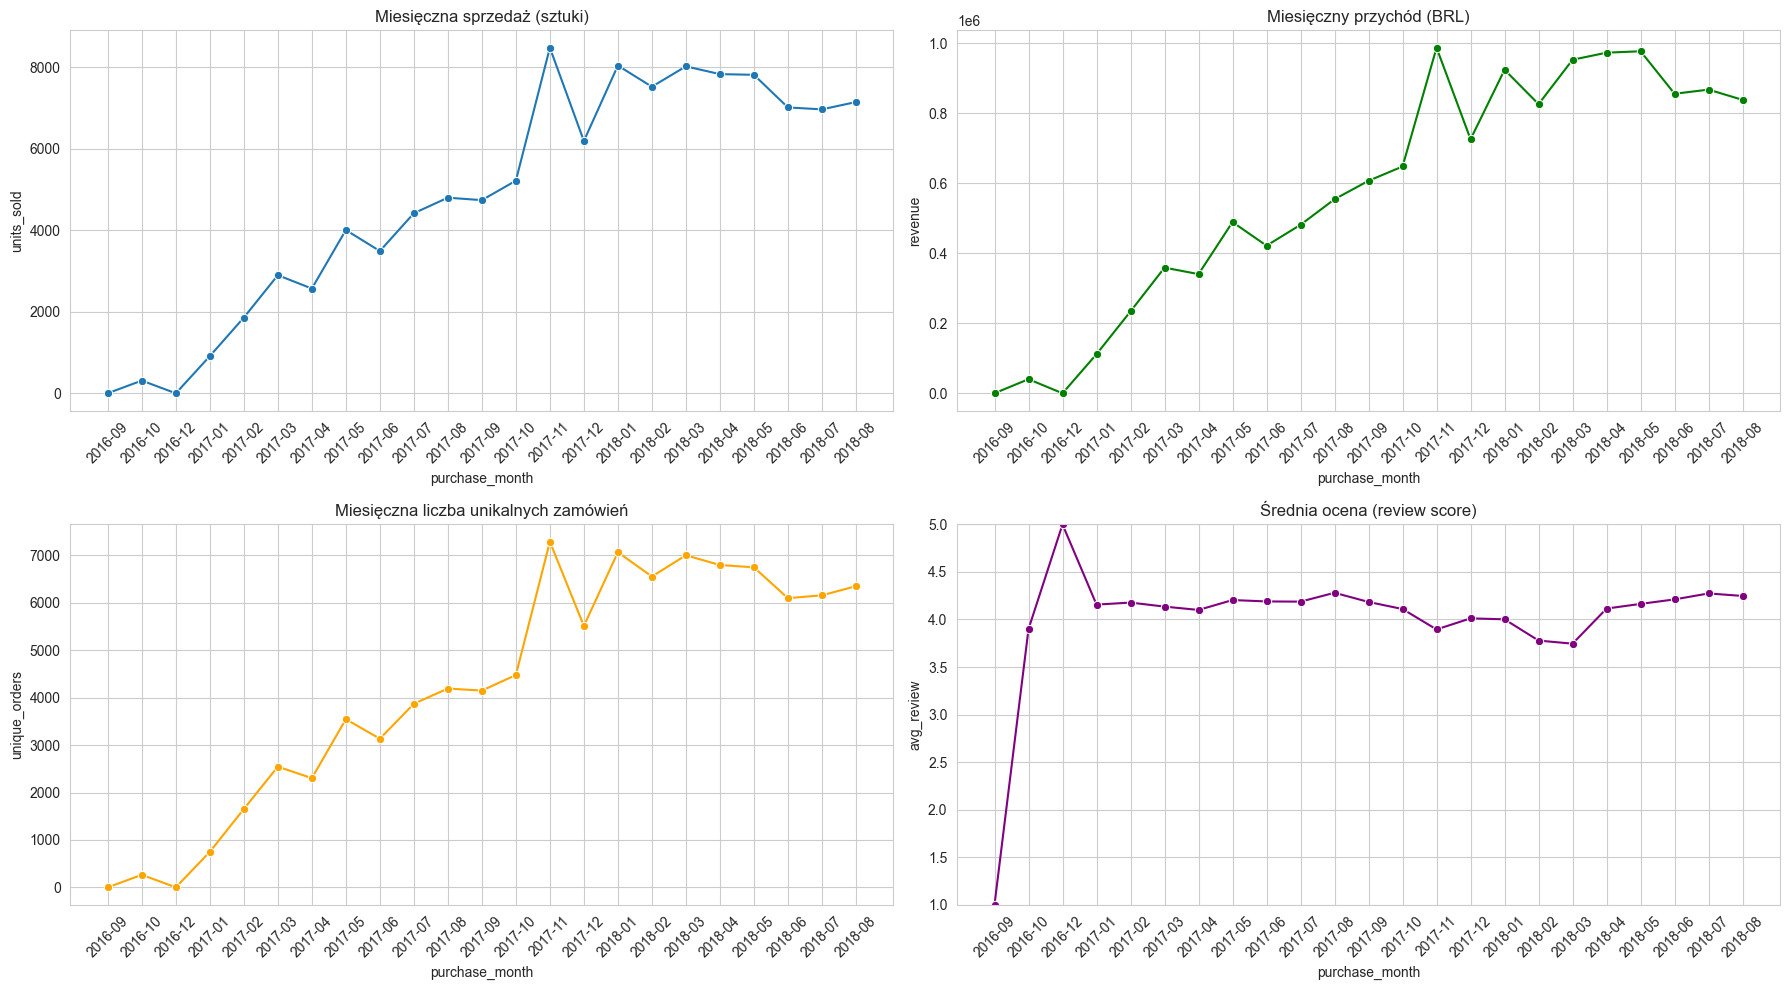

In [65]:
# ── Sprzedaż w czasie ──
delivered_df['purchase_month'] = delivered_df['order_purchase_timestamp'].dt.to_period('M')

monthly_data = (
    delivered_df.groupby('purchase_month')
    .agg(
        units_sold=('product_id', 'count'),
        revenue=('price', 'sum'),
        unique_orders=('order_id', 'nunique'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)
monthly_data['purchase_month'] = monthly_data['purchase_month'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.lineplot(data=monthly_data, x='purchase_month', y='units_sold', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Miesięczna sprzedaż (sztuki)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_data, x='purchase_month', y='revenue', marker='o', color='green', ax=axes[0, 1])
axes[0, 1].set_title('Miesięczny przychód (BRL)')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_data, x='purchase_month', y='unique_orders', marker='o', color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Miesięczna liczba unikalnych zamówień')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_data, x='purchase_month', y='avg_review', marker='o', color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Średnia ocena (review score)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim(1, 5)

plt.tight_layout()
plt.show()


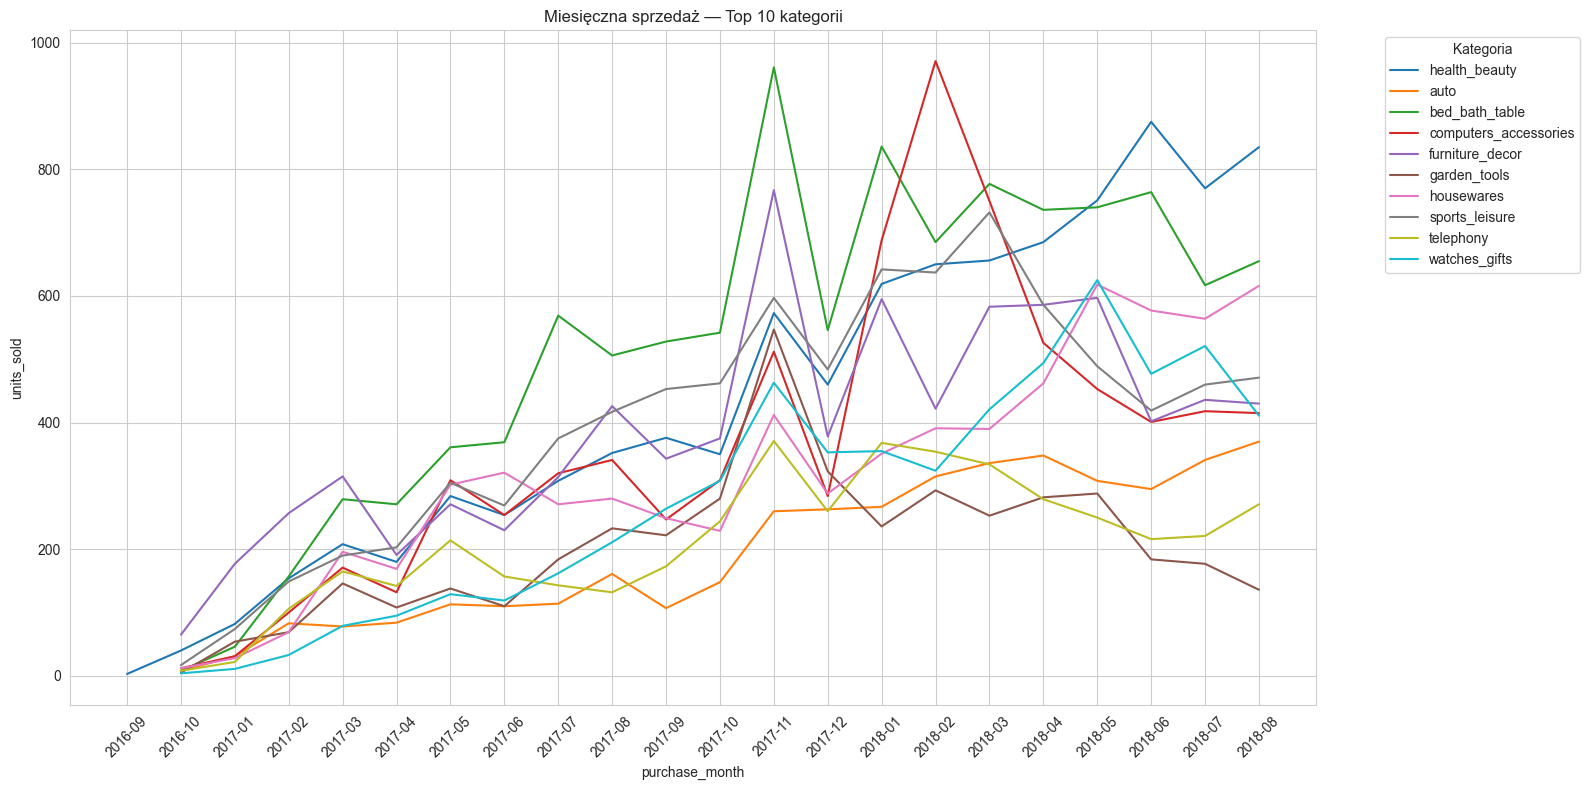

In [66]:
# ── Top 10 kategorii w czasie ──
top_10_cats = delivered_df['product_category_name_english'].value_counts().head(10).index

monthly_top = (
    delivered_df[delivered_df['product_category_name_english'].isin(top_10_cats)]
    .groupby(['purchase_month', 'product_category_name_english'])
    .size()
    .reset_index(name='units_sold')
)
monthly_top['purchase_month'] = monthly_top['purchase_month'].astype(str)

plt.figure(figsize=(16, 8))
sns.lineplot(data=monthly_top, x='purchase_month', y='units_sold', 
             hue='product_category_name_english')
plt.title('Miesięczna sprzedaż — Top 10 kategorii')
plt.xticks(rotation=45)
plt.legend(title='Kategoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

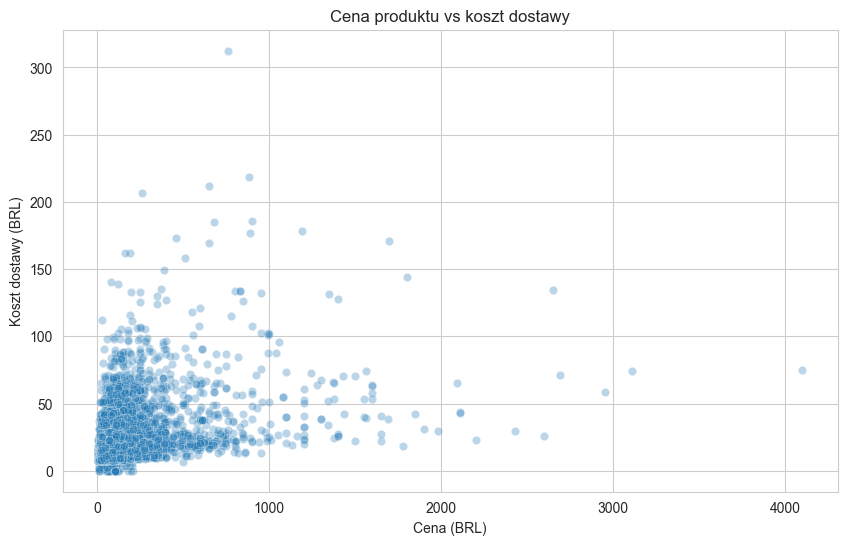

In [67]:
# ── Cena vs koszt dostawy ──
sample = delivered_df.sample(min(10000, len(delivered_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='price', y='freight_value', alpha=0.3)
plt.title('Cena produktu vs koszt dostawy')
plt.xlabel('Cena (BRL)')
plt.ylabel('Koszt dostawy (BRL)')
plt.show()

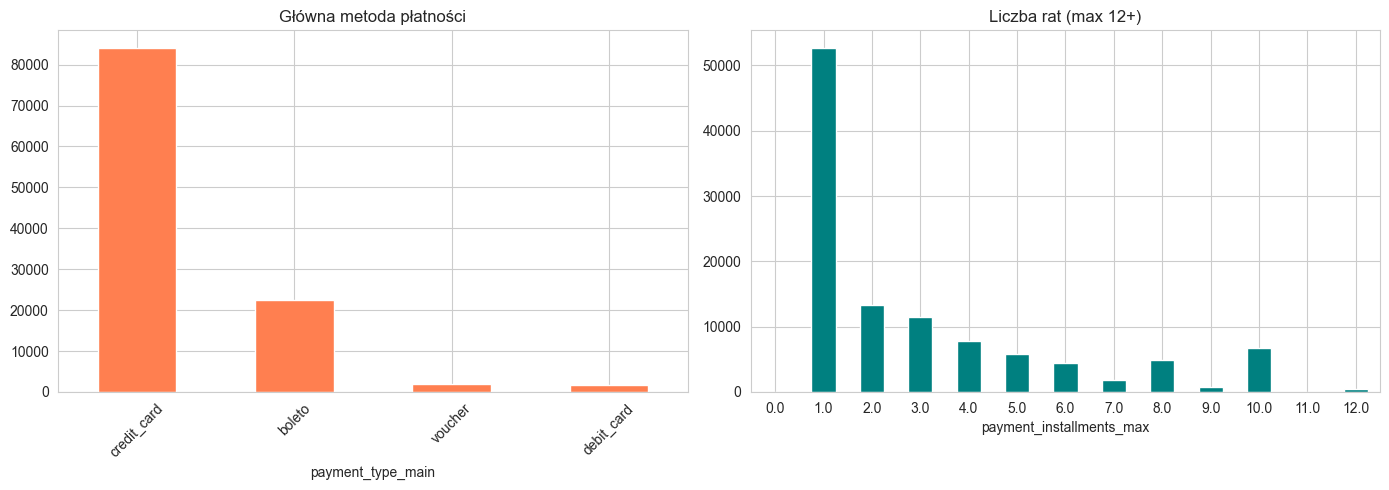

In [68]:
# ── Metody płatności ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivered_df['payment_type_main'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Główna metoda płatności')
axes[0].tick_params(axis='x', rotation=45)

delivered_df['payment_installments_max'].clip(upper=12).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Liczba rat (max 12+)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


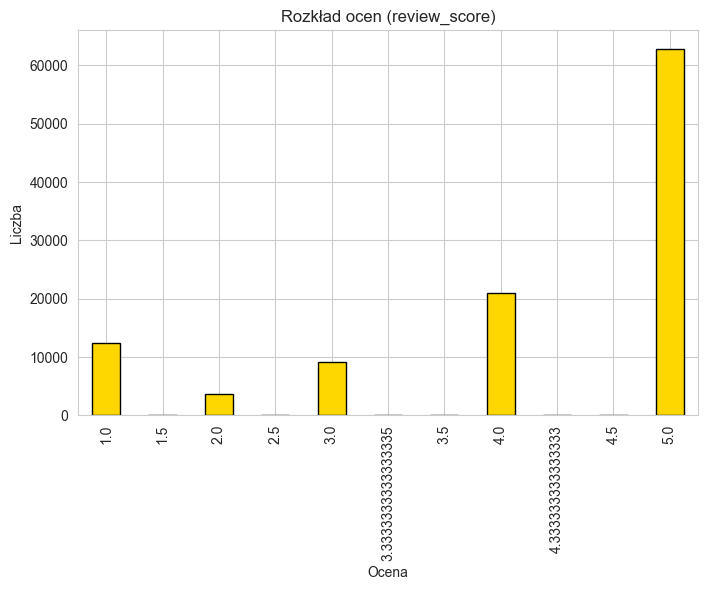

In [69]:
# ── Rozkład ocen ──
plt.figure(figsize=(8, 5))
delivered_df['review_score'].value_counts().sort_index().plot(kind='bar', color='gold', edgecolor='black')
plt.title('Rozkład ocen (review_score)')
plt.xlabel('Ocena')
plt.ylabel('Liczba')
plt.show()


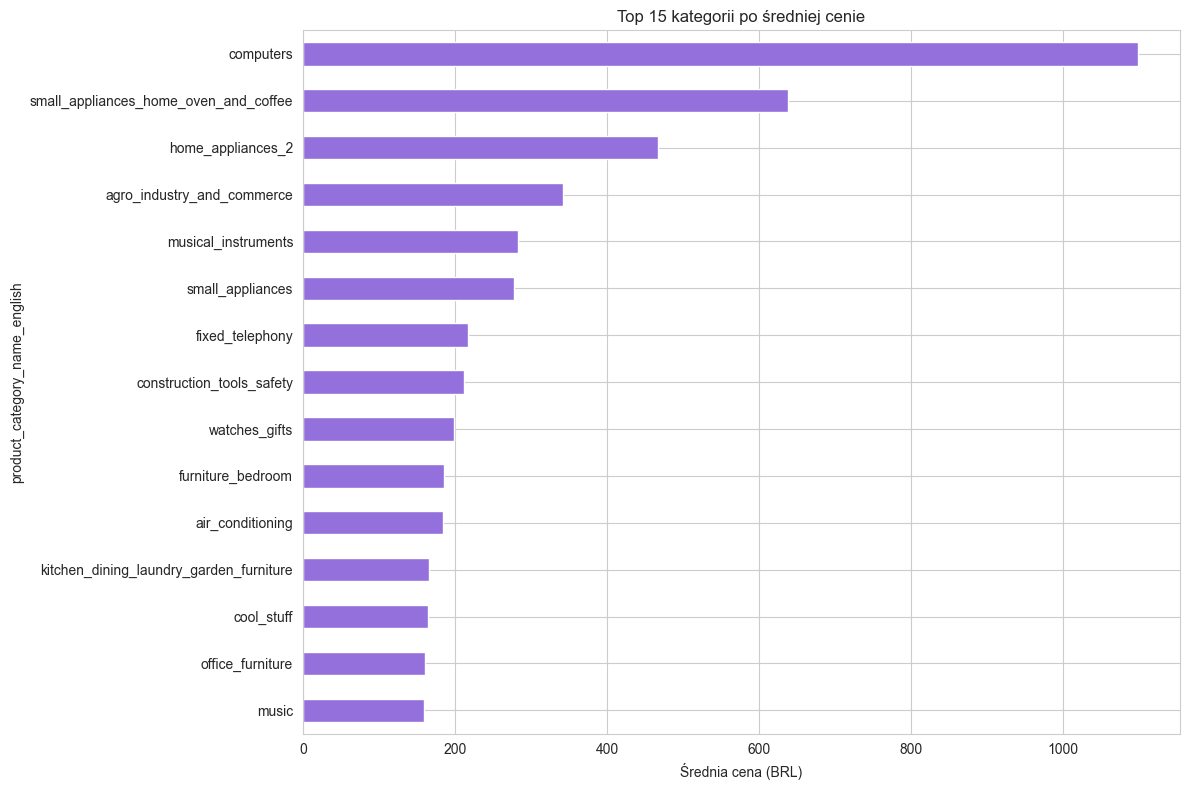

In [70]:
# ── Średnia cena per kategoria (top 15) ──
avg_price_cat = (
    delivered_df.groupby('product_category_name_english')['price']
    .mean().sort_values(ascending=False).head(15).sort_values()
)
plt.figure(figsize=(12, 8))
avg_price_cat.plot(kind='barh', color='mediumpurple')
plt.title('Top 15 kategorii po średniej cenie')
plt.xlabel('Średnia cena (BRL)')
plt.tight_layout()
plt.show()

## ⚙️ ETAP 2: Feature Engineering

Łączymy najlepsze pomysły z obu notebooków:
- **Z Twojego:** święta brazylijskie (is_holiday), target encoding, rolling std z oknem 12
- **Z Ariela:** momentum, pct_change, avg_price/freight lagi, is_month_start/end

### Strategia:
1. Agregacja do granulacji tygodniowej (kategoria × tydzień)
2. Uzupełnienie brakujących tygodni zerami
3. Cechy lag (opóźnione wartości)
4. Cechy rolling (średnia i odchylenie krocząca)
5. Momentum i pct_change
6. Cechy czasowe + święta
7. Target encoding + podział train/val/test

**Dlaczego tygodniowa granulacja?**
- Dziennie: za mało obserwacji na kategorię → szum
- Miesięcznie: za grubo → tracimy detale sezonowe  
- Tygodniowa: sweet spot dla ~100 kategorii × ~100 tygodni

In [71]:
# ── Przygotowanie danych ──
# Usuwamy braki TYLKO w kategorii (nie w całym df!)
ts_df = delivered_df[
    ['order_purchase_timestamp', 'product_category_name_english',
     'order_id', 'product_id', 'price', 'freight_value',
     'review_score', 'customer_state', 'seller_state',
     'payment_value_total', 'payment_installments_max']
].copy()

ts_df = ts_df.dropna(subset=['product_category_name_english']).copy()
print(f"Rekordów po usunięciu braków kategorii: {len(ts_df):,}")
print(f"Unikalnych kategorii: {ts_df['product_category_name_english'].nunique()}")
print(f"Zakres dat: {ts_df['order_purchase_timestamp'].min()} → {ts_df['order_purchase_timestamp'].max()}")

Rekordów po usunięciu braków kategorii: 108,638
Unikalnych kategorii: 71
Zakres dat: 2016-09-15 12:16:38 → 2018-08-29 15:00:37


### Krok 1 — Agregacja do granulacji tygodniowej

- `week_start` = poniedziałek każdego tygodnia (`freq='W-MON'`)
- `gmv` = suma cen (ile zarobiliśmy w tym tygodniu w tej kategorii)
- `order_count` = liczba zamówień (ile sztuk sprzedanych)

In [72]:
ts_df['purchase_week_start'] = (
    ts_df['order_purchase_timestamp']
    .dt.to_period('W')
    .apply(lambda r: r.start_time)
)

weekly_df = (
    ts_df.groupby(['product_category_name_english', 'purchase_week_start'])
    .agg(
        units_sold=('product_id', 'count'),
        unique_orders=('order_id', 'nunique'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        avg_freight=('freight_value', 'mean'),
        avg_review=('review_score', 'mean'),
        avg_payment_value=('payment_value_total', 'mean'),
        avg_installments=('payment_installments_max', 'mean')
    )
    .reset_index()
)

print(f"weekly_df: {weekly_df.shape}")
print(f"Zakres: {weekly_df['purchase_week_start'].min()} → {weekly_df['purchase_week_start'].max()}")
print(f"Kategorii: {weekly_df['product_category_name_english'].nunique()}")


weekly_df: (4359, 10)
Zakres: 2016-09-12 00:00:00 → 2018-08-27 00:00:00
Kategorii: 71


### Krok 2 — Uzupełnienie brakujących tygodni zerami

In [73]:
all_categories = weekly_df['product_category_name_english'].unique()
all_weeks = pd.date_range(
    start=weekly_df['purchase_week_start'].min(),
    end=weekly_df['purchase_week_start'].max(),
    freq='W-MON'
)

full_index = pd.MultiIndex.from_product(
    [all_categories, all_weeks],
    names=['product_category_name_english', 'purchase_week_start']
)

weekly_full = (
    weekly_df.set_index(['product_category_name_english', 'purchase_week_start'])
    .reindex(full_index)
    .reset_index()
)

# Zera dla tygodni bez sprzedaży
for col in ['units_sold', 'unique_orders', 'revenue']:
    weekly_full[col] = weekly_full[col].fillna(0)
for col in ['avg_price', 'avg_freight', 'avg_review', 'avg_payment_value', 'avg_installments']:
    weekly_full[col] = weekly_full[col].fillna(0)

weekly_full = weekly_full.sort_values(
    ['product_category_name_english', 'purchase_week_start']
).reset_index(drop=True)

print(f"Po uzupełnieniu: {weekly_full.shape}")
print(f"Tygodnie z units_sold=0: {(weekly_full['units_sold']==0).sum()} "
      f"({(weekly_full['units_sold']==0).mean()*100:.1f}%)")

Po uzupełnieniu: (7313, 10)
Tygodnie z units_sold=0: 2954 (40.4%)


### Krok 3 — Cechy lag 
**Lag** = wartość z N tygodni temu. `lag_1` = sprzedaż w poprzednim tygodniu.

**Dlaczego to najważniejsze cechy?** Sprzedaż w tym tygodniu jest silnie skorelowana 
ze sprzedażą w poprzednich. Jeśli tydzień temu sprzedałeś 100 sztuk → prawdopodobnie 
ten tydzień też ~100.

**Dlaczego shift(N)?** Żeby uniknąć data leakage — model w momencie predykcji nie zna przyszłości.

In [74]:
for lag in [1, 2, 4, 8]:
    weekly_full[f'lag_{lag}'] = (
        weekly_full.groupby('product_category_name_english')['units_sold'].shift(lag)
    )

# Lagi dodatkowe (revenue, zamówienia, cena)
weekly_full['revenue_lag_1'] = weekly_full.groupby('product_category_name_english')['revenue'].shift(1)
weekly_full['orders_lag_1'] = weekly_full.groupby('product_category_name_english')['unique_orders'].shift(1)
weekly_full['avg_price_lag_1'] = weekly_full.groupby('product_category_name_english')['avg_price'].shift(1)

lag_cols = [c for c in weekly_full.columns if 'lag' in c]
print(f"Cechy lag ({len(lag_cols)}): {lag_cols}")

Cechy lag (7): ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1']


### Krok 4 — Cechy rolling (średnia i odchylenie krocząca)
**Rolling mean** = średnia z ostatnich N tygodni → wygładza szum, pokazuje trend.  
**shift(1) przed rolling** → żeby model nie podglądał bieżącego tygodnia.

In [75]:
for window in [4, 8]:
    weekly_full[f'rolling_mean_{window}'] = (
        weekly_full.groupby('product_category_name_english')['units_sold']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=2).mean())
    )
    weekly_full[f'rolling_std_{window}'] = (
        weekly_full.groupby('product_category_name_english')['units_sold']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=2).std())
    )

# Rolling na revenue
weekly_full['revenue_roll_mean_4'] = (
    weekly_full.groupby('product_category_name_english')['revenue']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
)
weekly_full['revenue_roll_std_4'] = (
    weekly_full.groupby('product_category_name_english')['revenue']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).std())
)

roll_cols = [c for c in weekly_full.columns if 'roll' in c]
print(f"Cechy rolling ({len(roll_cols)}): {roll_cols}")


Cechy rolling (6): ['rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'revenue_roll_mean_4', 'revenue_roll_std_4']


### Krok 5 — Momentum i pct_change 

- **Momentum** = lag_1 − rolling_mean → powyżej/poniżej trendu?
- **pct_change** = procentowa zmiana tydzień do tygodnia


In [76]:
weekly_full['momentum_1_4'] = weekly_full['lag_1'] - weekly_full['rolling_mean_4']
weekly_full['momentum_1_8'] = weekly_full['lag_1'] - weekly_full['rolling_mean_8']

weekly_full['units_pct_change_1'] = (
    weekly_full.groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).pct_change())
)
weekly_full['revenue_pct_change_1'] = (
    weekly_full.groupby('product_category_name_english')['revenue']
    .transform(lambda x: x.shift(1).pct_change())
)

print("Momentum i pct_change dodane ✓")

Momentum i pct_change dodane ✓


### Krok 6 — Cechy czasowe + święta brazylijskie

In [77]:
weekly_full['year'] = weekly_full['purchase_week_start'].dt.year
weekly_full['month'] = weekly_full['purchase_week_start'].dt.month
weekly_full['quarter'] = weekly_full['purchase_week_start'].dt.quarter
weekly_full['week_of_year'] = weekly_full['purchase_week_start'].dt.isocalendar().week.astype(int)
weekly_full['is_month_start'] = weekly_full['purchase_week_start'].dt.is_month_start.astype(int)
weekly_full['is_month_end'] = weekly_full['purchase_week_start'].dt.is_month_end.astype(int)

br_holidays = [
    # Boże Narodzenie i Nowy Rok
    '2016-12-25', '2017-01-01', '2017-12-25', '2018-01-01', '2018-12-25',
    # Dzień Matki (2. niedziela maja) → silny peak sprzedaży
    '2016-05-08', '2017-05-14', '2018-05-13',
    # Karnawał
    '2017-02-27', '2017-02-28', '2018-02-12', '2018-02-13',
    # Black Friday (4. piątek listopada)
    '2016-11-25', '2017-11-24', '2018-11-23',
    # Dzień Dziecka (12 października)
    '2016-10-12', '2017-10-12', '2018-10-12',
]
br_holidays_dt = pd.to_datetime(br_holidays)


def is_holiday_week(week_start):
    week_dates = pd.date_range(week_start, periods=7)
    return int(any(h in week_dates for h in br_holidays_dt))

weekly_full['is_holiday'] = weekly_full['purchase_week_start'].apply(is_holiday_week)


print(f"Cechy czasowe dodane ✓")
print(f"Tygodnie ze świętem: {weekly_full['is_holiday'].sum()}")

Cechy czasowe dodane ✓
Tygodnie ze świętem: 852


### Krok 7  — Target encoding + podział train/val/test

In [78]:
# ── Czyszczenie inf ──
weekly_full = weekly_full.replace([np.inf, -np.inf], np.nan)

# ── Usunięcie wierszy bez lagów (pierwsze tygodnie) ──
feature_df = weekly_full.dropna(
    subset=['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_mean_8']
).copy()

print(f"weekly_full: {weekly_full.shape}")
print(f"feature_df: {feature_df.shape}")
print(f"Usunięto: {len(weekly_full) - len(feature_df)} wierszy (brak lagów)")

weekly_full: (7313, 34)
feature_df: (7029, 34)
Usunięto: 284 wierszy (brak lagów)


In [79]:
from sklearn.preprocessing import LabelEncoder

# ── Label encoding kategorii ──
le = LabelEncoder()
feature_df['category_enc'] = le.fit_transform(feature_df['product_category_name_english'])

# ── Podział chronologiczny 70/15/15 ──
sorted_dates = sorted(feature_df['purchase_week_start'].unique())
n_dates = len(sorted_dates)

train_end_date = sorted_dates[int(n_dates * 0.70) - 1]
valid_end_date = sorted_dates[int(n_dates * 0.85) - 1]

train_mask = feature_df['purchase_week_start'] <= train_end_date
val_mask = (feature_df['purchase_week_start'] > train_end_date) & (feature_df['purchase_week_start'] <= valid_end_date)
test_mask = feature_df['purchase_week_start'] > valid_end_date

print(f"Train: {train_mask.sum():>6,} wierszy  ({feature_df.loc[train_mask, 'purchase_week_start'].min().date()} → {feature_df.loc[train_mask, 'purchase_week_start'].max().date()})")
print(f"Val:   {val_mask.sum():>6,} wierszy  ({feature_df.loc[val_mask, 'purchase_week_start'].min().date()} → {feature_df.loc[val_mask, 'purchase_week_start'].max().date()})")
print(f"Test:  {test_mask.sum():>6,} wierszy  ({feature_df.loc[test_mask, 'purchase_week_start'].min().date()} → {feature_df.loc[test_mask, 'purchase_week_start'].max().date()})")

# ── Wyczyść gdyby kolumna została z poprzedniej próby ──
if 'category_mean_units' in feature_df.columns:
    feature_df = feature_df.drop(columns=['category_mean_units'])

# ── Target encoding (TYLKO z train!) ──
target_enc_map = (
    feature_df[feature_df['purchase_week_start'] <= train_end_date]
    .groupby('product_category_name_english')['units_sold']
    .mean()
    .reset_index()
    .rename(columns={'units_sold': 'category_mean_units'})
)

feature_df = feature_df.merge(target_enc_map, on='product_category_name_english', how='left')

# Fillna globalną średnią
global_mean = feature_df[feature_df['purchase_week_start'] <= train_end_date]['units_sold'].mean()
feature_df['category_mean_units'] = feature_df['category_mean_units'].fillna(global_mean)

# ── Przelicz maski (merge zmienia indeks) ──
train_mask = feature_df['purchase_week_start'] <= train_end_date
val_mask = (feature_df['purchase_week_start'] > train_end_date) & (feature_df['purchase_week_start'] <= valid_end_date)
test_mask = feature_df['purchase_week_start'] > valid_end_date

print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")
print(f"\nTarget encoding — top 5:")
print(target_enc_map.sort_values('category_mean_units', ascending=False).head())

Train:  4,899 wierszy  (2016-10-10 → 2018-01-29)
Val:    1,065 wierszy  (2018-02-05 → 2018-05-14)
Test:   1,065 wierszy  (2018-05-21 → 2018-08-27)
Train: 4,899  Val: 1,065  Test: 1,065

Target encoding — top 5:
   product_category_name_english  category_mean_units
7                 bed_bath_table            87.898551
65                sports_leisure            68.043478
39               furniture_decor            68.014493
43                 health_beauty            62.086957
15         computers_accessories            55.043478


In [80]:
# ── Wyczyść gdyby kolumna została z poprzedniej próby ──
if 'category_mean_units' in feature_df.columns:
    feature_df = feature_df.drop(columns=['category_mean_units'])

# ── Target encoding (TYLKO z train!) ──
target_enc_map = (
    feature_df[feature_df['purchase_week_start'] <= train_end_date]
    .groupby('product_category_name_english')['units_sold']
    .mean()
    .reset_index()
    .rename(columns={'units_sold': 'category_mean_units'})
)

feature_df = feature_df.merge(target_enc_map, on='product_category_name_english', how='left')

# Fillna globalną średnią
global_mean = feature_df[feature_df['purchase_week_start'] <= train_end_date]['units_sold'].mean()
feature_df['category_mean_units'] = feature_df['category_mean_units'].fillna(global_mean)

# ── Przelicz maski (merge zmienia indeks) ──
train_mask = feature_df['purchase_week_start'] <= train_end_date
val_mask = (feature_df['purchase_week_start'] > train_end_date) & (feature_df['purchase_week_start'] <= valid_end_date)
test_mask = feature_df['purchase_week_start'] > valid_end_date

print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")
print(f"\nTarget encoding — top 5:")
print(target_enc_map.sort_values('category_mean_units', ascending=False).head())

Train: 4,899  Val: 1,065  Test: 1,065

Target encoding — top 5:
   product_category_name_english  category_mean_units
7                 bed_bath_table            87.898551
65                sports_leisure            68.043478
39               furniture_decor            68.014493
43                 health_beauty            62.086957
15         computers_accessories            55.043478


In [81]:
# ── Definicja cech (połączone z obu notebooków) ──
FEATURES = [
    # Lagi units_sold
    'lag_1', 'lag_2', 'lag_4', 'lag_8',
    # Lagi dodatkowe
    'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1',
    # Rolling units_sold
    'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8',
    # Rolling revenue
    'revenue_roll_mean_4', 'revenue_roll_std_4',
    # Momentum (z Ariela)
    'momentum_1_4', 'momentum_1_8',
    # Pct change (z Ariela)
    'units_pct_change_1', 'revenue_pct_change_1',
    # Bazowe
    'avg_price', 'avg_freight',
    # Czas
    'year', 'month', 'quarter', 'week_of_year',
    'is_month_start', 'is_month_end', 'is_holiday',
    # Kategoria
    'category_enc', 'category_mean_units',
]

TARGET = 'units_sold'

# Wypełnij NaN w niestabilnych cechach
for col in ['units_pct_change_1', 'revenue_pct_change_1', 
            'rolling_std_4', 'rolling_std_8', 'revenue_roll_std_4']:
    feature_df[col] = feature_df[col].fillna(0)

# ── Finalne X i y ──
X_train = feature_df.loc[train_mask, FEATURES].copy()
y_train = feature_df.loc[train_mask, TARGET].copy()
X_val = feature_df.loc[val_mask, FEATURES].copy()
y_val = feature_df.loc[val_mask, TARGET].copy()
X_test = feature_df.loc[test_mask, FEATURES].copy()
y_test = feature_df.loc[test_mask, TARGET].copy()

print(f"Liczba cech: {len(FEATURES)}")
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

# Check NaN
for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f"NaN w X_{name}: {X.isnull().sum().sum()}")


Liczba cech: 28
X_train: (4899, 28)  y_train: (4899,)
X_val:   (1065, 28)  y_val:   (1065,)
X_test:  (1065, 28)  y_test:  (1065,)
NaN w X_train: 284
NaN w X_val: 0
NaN w X_test: 0


## 📊 Analiza korelacji

**Po co korelacja?**
1. Które cechy najsilniej wpływają na target (units_sold)?
2. Które cechy ze sobą "duplikują" informację (multicolinearność)?

Dla **regresji liniowej** multicolinearność to duży problem (niestabilne współczynniki).  
Dla **LightGBM** — mniejszy (drzewa sobie radzą).

In [82]:
# ── Korelacja z targetem ──
corr_data = feature_df[FEATURES + [TARGET]].copy()
target_corr = corr_data.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("KORELACJA CECH Z TARGETEM (units_sold)")
print("\nNajsilniej skorelowane:")
print(target_corr.head(10).round(3).to_string())
print("\nNajsłabiej skorelowane:")
print(target_corr.tail(5).round(3).to_string())



KORELACJA CECH Z TARGETEM (units_sold)

Najsilniej skorelowane:
orders_lag_1           0.927
lag_1                  0.927
rolling_mean_8         0.912
rolling_mean_4         0.907
lag_2                  0.879
revenue_lag_1          0.860
revenue_roll_mean_4    0.854
lag_8                  0.847
lag_4                  0.841
category_mean_units    0.755

Najsłabiej skorelowane:
is_holiday             -0.010
revenue_pct_change_1   -0.013
week_of_year           -0.048
month                  -0.048
quarter                -0.049


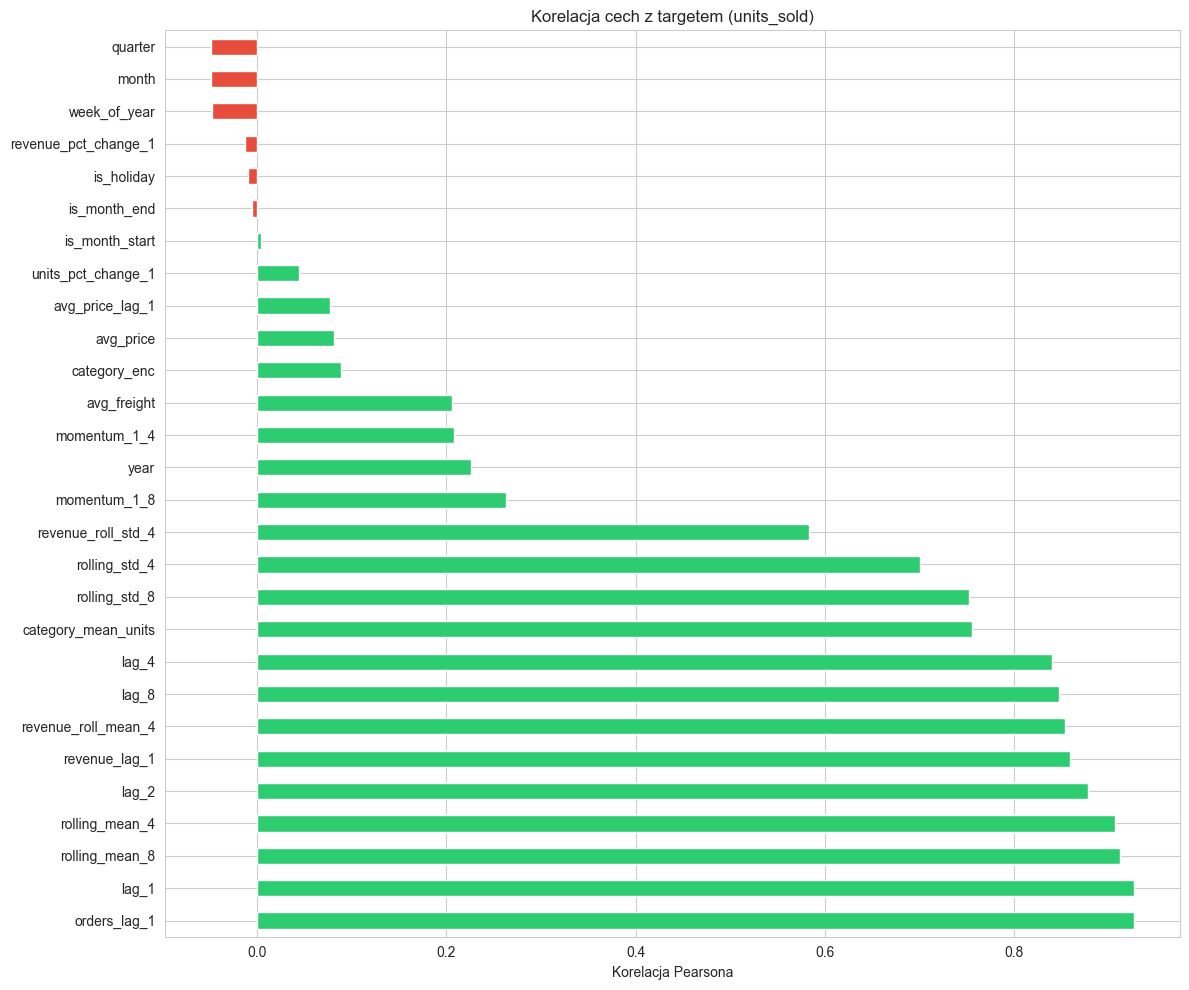

In [83]:
# ── Wykres korelacji z targetem ──
plt.figure(figsize=(12, 10))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title(f'Korelacja cech z targetem ({TARGET})')
plt.xlabel('Korelacja Pearsona')
plt.tight_layout()
plt.show()

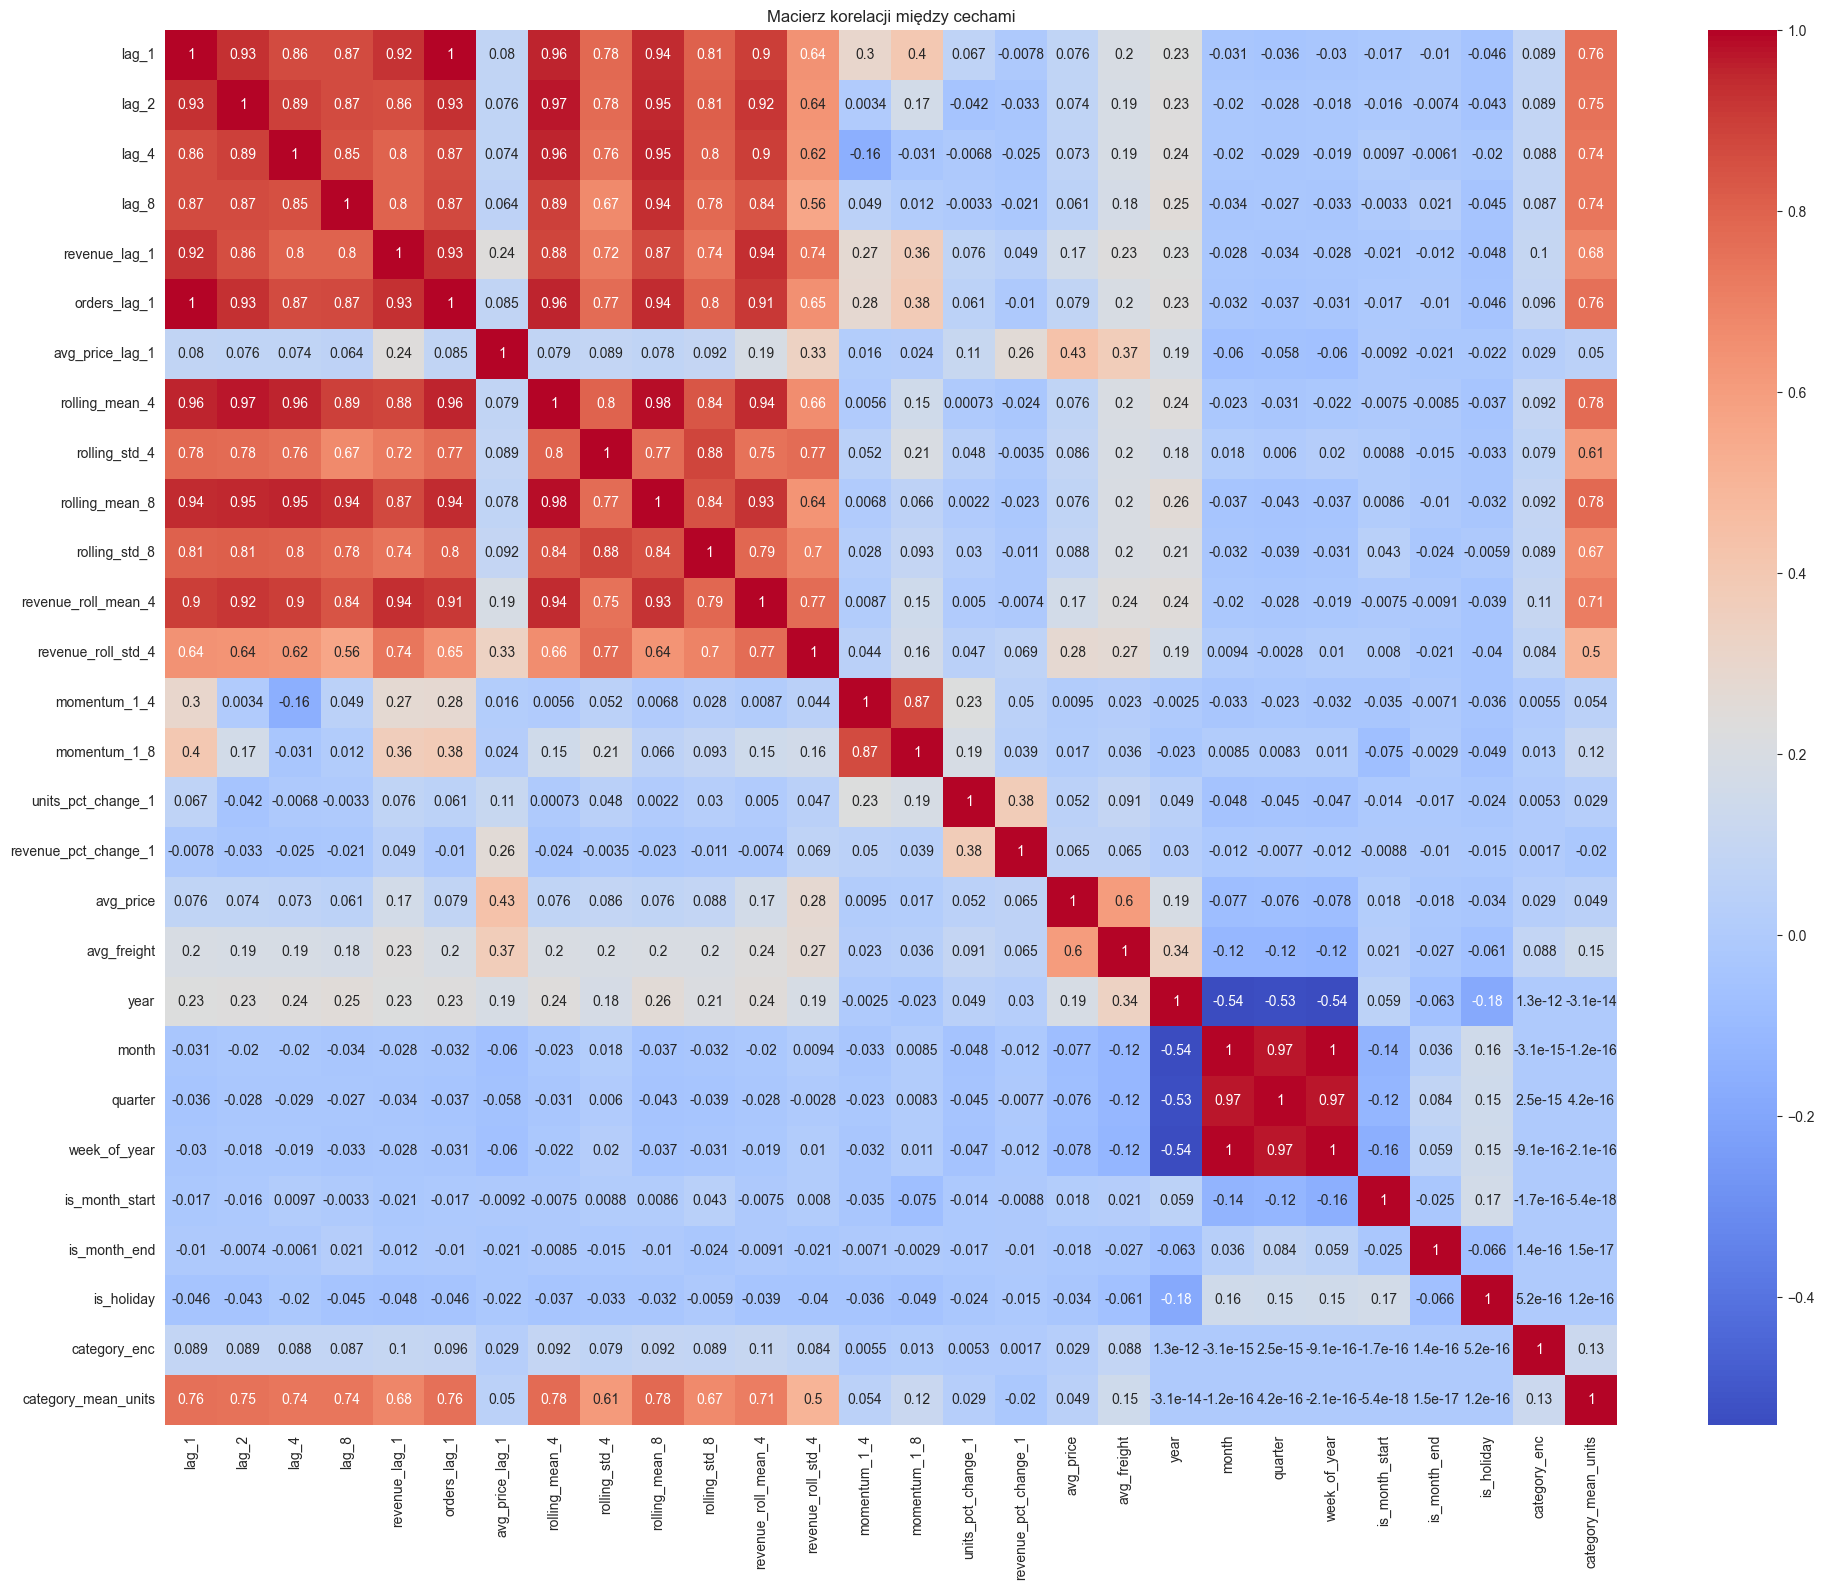

In [84]:
# ── Heatmapa korelacji ──
plt.figure(figsize=(20, 16))
corr_matrix = corr_data[FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, annot=True, 
    cmap='coolwarm'
)
plt.title('Macierz korelacji między cechami')
plt.tight_layout()
plt.show()





## 🤖 ETAP 3: Model

### 3 modele do porównania:
1. **Baseline (lag_1)** — predykcja = sprzedaż z poprzedniego tygodnia
2. **Ridge Regression** (regresja liniowa z regularyzacją L2)
3. **LightGBM** (gradient boosting)

### Dlaczego Ridge a nie zwykła regresja liniowa?
Mamy skorelowane cechy → zwykła regresja daje niestabilne współczynniki. 
Ridge "karze" za duże wagi → bardziej stabilny model.

### Metryki:
- **RMSE** — kara kwadratowa za duże błędy (wrażliwe na outliery)
- **MAE** — średni błąd bezwzględny (bardziej odporny)
- **MAPE** — błąd procentowy (ignoruje zera w danych)


In [85]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred, dataset=''):
    r = rmse(y_true, y_pred)
    m = mean_absolute_error(y_true, y_pred)
    mp = mape(y_true, y_pred)
    print(f"{name:25s} [{dataset:10s}] RMSE: {r:8.3f} | MAE: {m:8.3f} | MAPE: {mp:6.1f}%")
    return {'model': name, 'dataset': dataset, 'RMSE': r, 'MAE': m, 'MAPE': mp}

results = []
print("Funkcje ewaluacji gotowe ✓")

Funkcje ewaluacji gotowe ✓


### Model 1: Baseline (lag_1)

In [86]:
# ── BASELINE ──
results.append(evaluate('Baseline (lag_1)', y_val, X_val['lag_1'], 'Validation'))
results.append(evaluate('Baseline (lag_1)', y_test, X_test['lag_1'], 'Test'))

Baseline (lag_1)          [Validation] RMSE:   11.707 | MAE:    5.851 | MAPE:   54.4%
Baseline (lag_1)          [Test      ] RMSE:   16.981 | MAE:    8.080 | MAPE:  102.5%


### Model 2: Ridge Regression

In [87]:
from sklearn.linear_model import Ridge

# Wypełnij NaN zerami (Ridge nie akceptuje braków)
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

print(f"NaN po czyszczeniu — train: {X_train.isnull().sum().sum()}, val: {X_val.isnull().sum().sum()}, test: {X_test.isnull().sum().sum()}")

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred_val = np.maximum(ridge.predict(X_val), 0)
ridge_pred_test = np.maximum(ridge.predict(X_test), 0)

results.append(evaluate('Ridge Regression', y_val, ridge_pred_val, 'Validation'))
results.append(evaluate('Ridge Regression', y_test, ridge_pred_test, 'Test'))

NaN po czyszczeniu — train: 0, val: 0, test: 0
Ridge Regression          [Validation] RMSE:   12.500 | MAE:    6.681 | MAPE:   80.0%
Ridge Regression          [Test      ] RMSE:   17.081 | MAE:    8.338 | MAPE:  122.9%


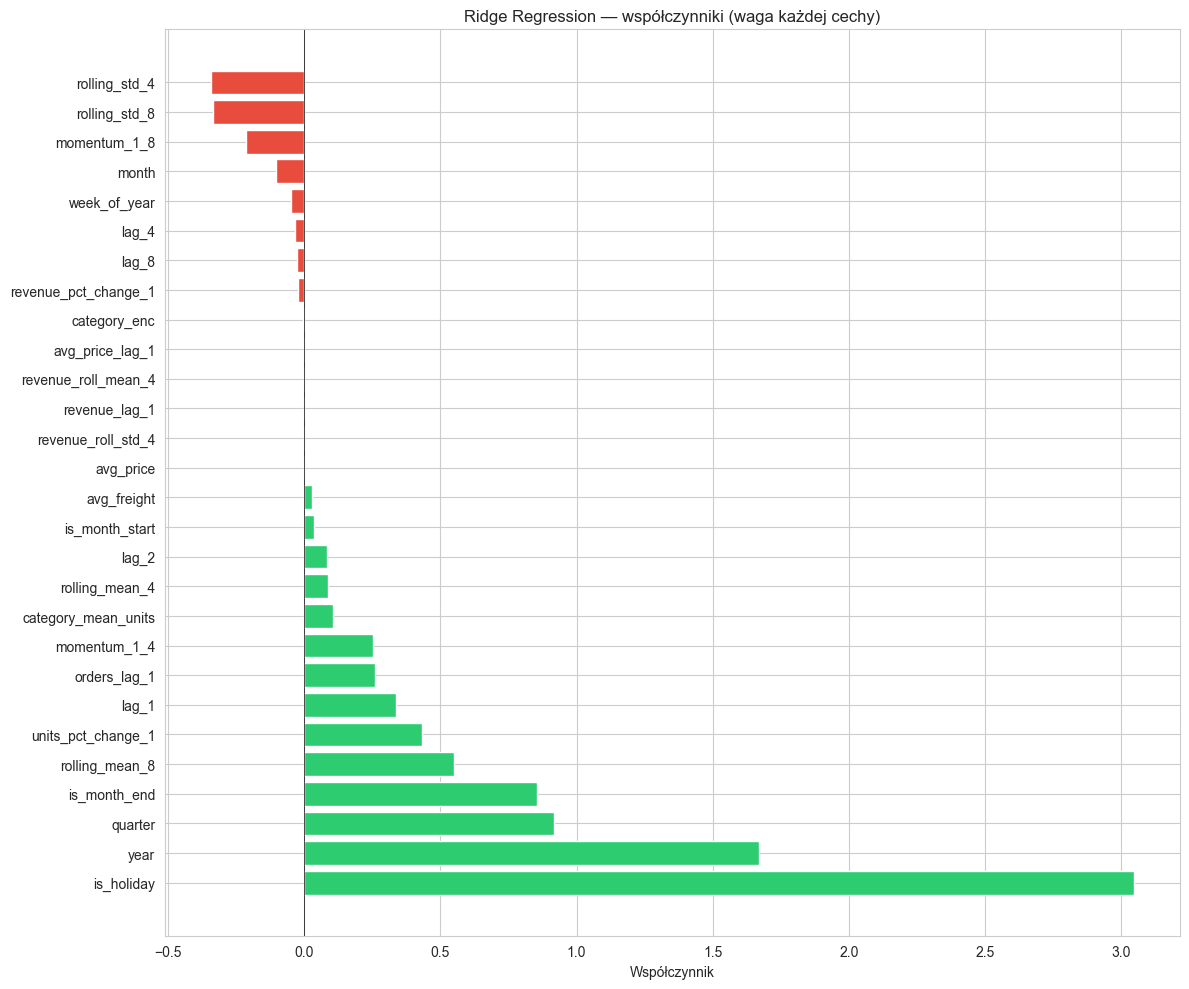

Top 5 najważniejszych cech (wg |współczynnika|):
       feature  coefficient
    is_holiday     3.045710
          year     1.669352
       quarter     0.915593
  is_month_end     0.854011
rolling_mean_8     0.549686


In [88]:
# ── Współczynniki Ridge ──
coef_df = pd.DataFrame({
    'feature': FEATURES, 'coefficient': ridge.coef_
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(12, 10))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.title('Ridge Regression — współczynniki (waga każdej cechy)')
plt.xlabel('Współczynnik')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 5 najważniejszych cech (wg |współczynnika|):")
coef_df['abs'] = coef_df['coefficient'].abs()
print(coef_df.nlargest(5, 'abs')[['feature', 'coefficient']].to_string(index=False))


### Model 3: LightGBM

**LightGBM** buduje drzewa decyzyjne jedno po drugim, gdzie każde następne poprawia 
błędy poprzedniego. State-of-the-art dla danych tabelarycznych.

**Early stopping** — zatrzymuje trening, gdy wynik na validation przestaje się poprawiać.
Zapobiega overfittingowi bez konieczności ręcznego dobierania `n_estimators`.


In [89]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

lgb_pred_val = np.maximum(lgb_model.predict(X_val), 0)
lgb_pred_test = np.maximum(lgb_model.predict(X_test), 0)

results.append(evaluate('LightGBM', y_val, lgb_pred_val, 'Validation'))
results.append(evaluate('LightGBM', y_test, lgb_pred_test, 'Test'))


Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 162.554
[100]	valid_0's l2: 144.334
[150]	valid_0's l2: 143.793
Early stopping, best iteration is:
[142]	valid_0's l2: 142.718
LightGBM                  [Validation] RMSE:   11.946 | MAE:    5.604 | MAPE:   47.0%
LightGBM                  [Test      ] RMSE:   16.988 | MAE:    7.686 | MAPE:   99.2%


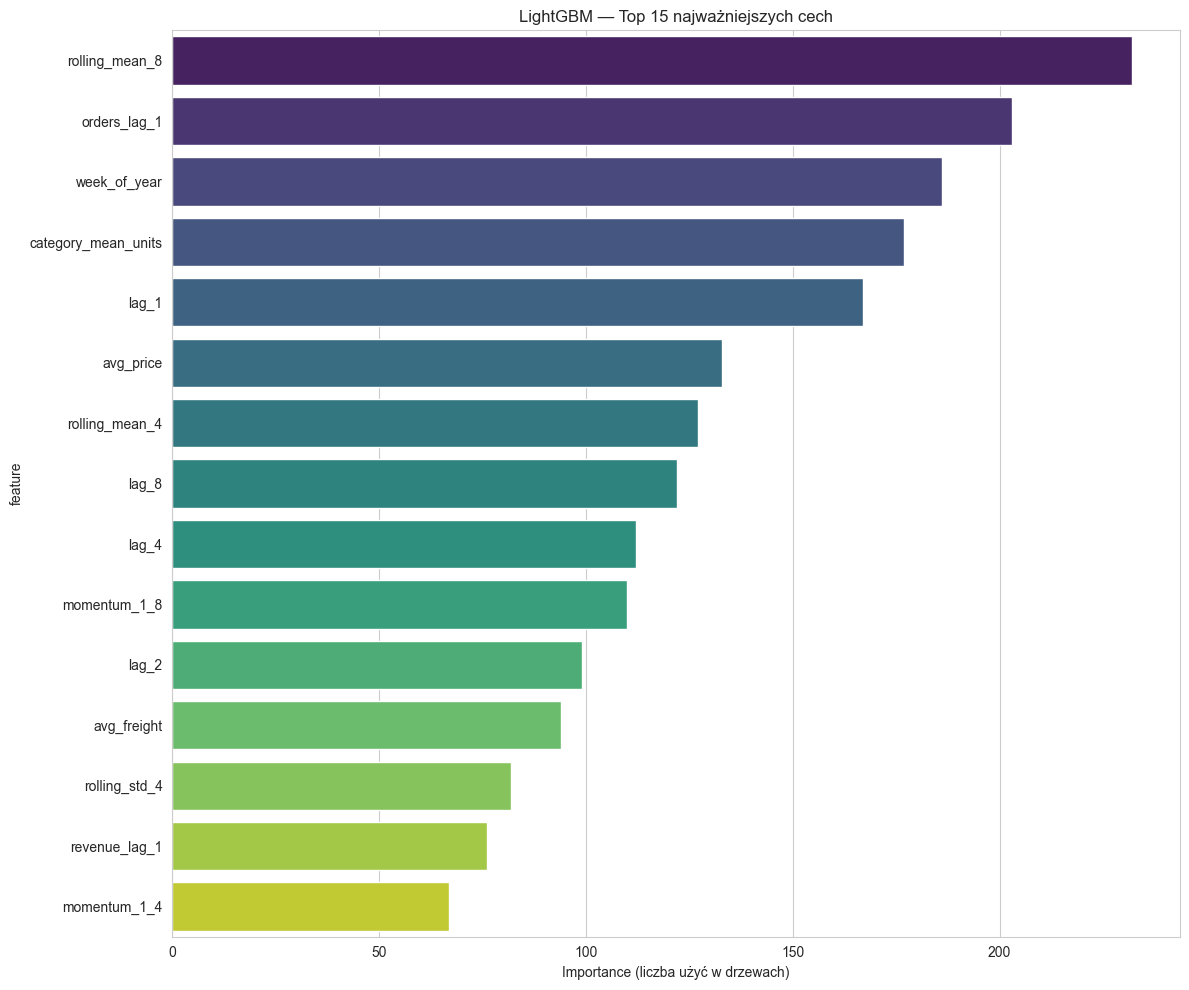

Top 10 cech:
            feature  importance
     rolling_mean_8         232
       orders_lag_1         203
       week_of_year         186
category_mean_units         177
              lag_1         167
          avg_price         133
     rolling_mean_4         127
              lag_8         122
              lag_4         112
       momentum_1_8         110


In [90]:
# ── Feature importance ──
importance_df = pd.DataFrame({
    'feature': FEATURES, 'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('LightGBM — Top 15 najważniejszych cech')
plt.xlabel('Importance (liczba użyć w drzewach)')
plt.tight_layout()
plt.show()

print("Top 10 cech:")
print(importance_df.head(10).to_string(index=False))

### Porównanie modeli


PORÓWNANIE MODELI
           model    dataset      RMSE      MAE       MAPE
Baseline (lag_1) Validation 11.706866 5.850704  54.368209
Baseline (lag_1)       Test 16.980934 8.079812 102.476479
Ridge Regression Validation 12.500080 6.681274  80.019301
Ridge Regression       Test 17.081393 8.338294 122.885765
        LightGBM Validation 11.946472 5.604388  46.992303
        LightGBM       Test 16.988401 7.686201  99.151344


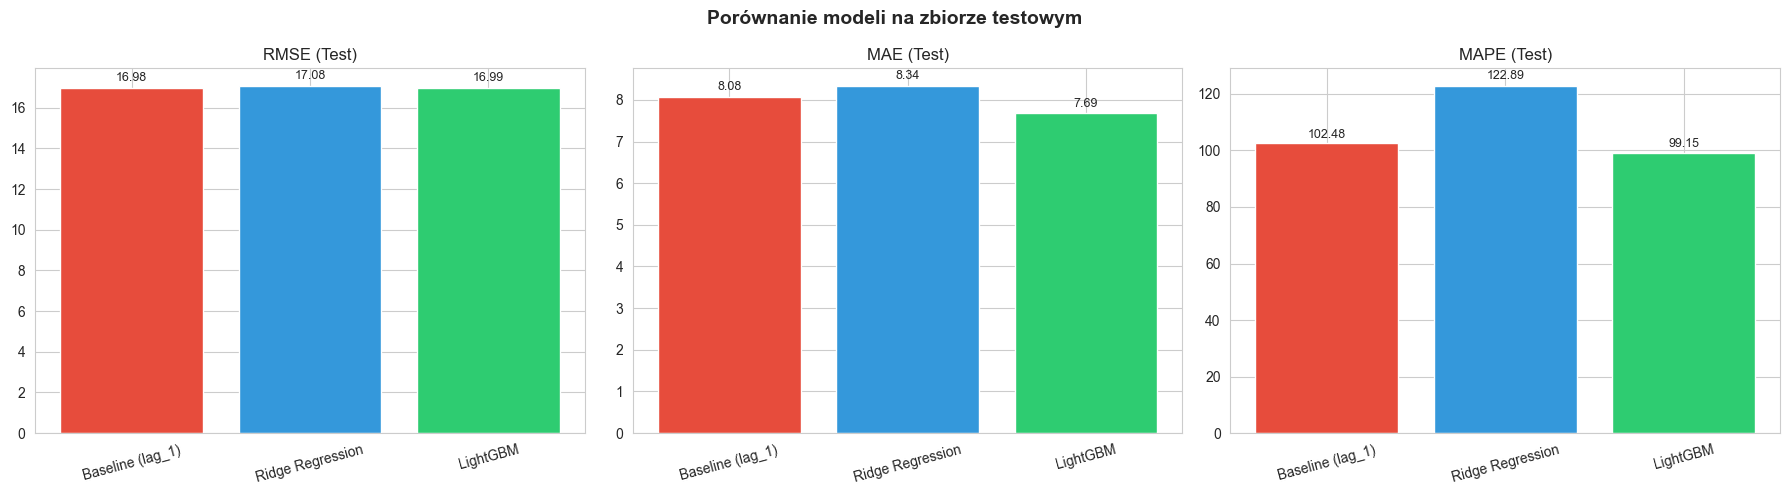

In [91]:
# ── Porównanie ──
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("PORÓWNANIE MODELI")
print("=" * 80)
print(results_df.to_string(index=False))

# Wizualizacja
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_res = results_df[results_df['dataset'] == 'Test']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, metric in enumerate(['RMSE', 'MAE', 'MAPE']):
    axes[i].bar(test_res['model'], test_res[metric], color=colors)
    axes[i].set_title(f'{metric} (Test)')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(test_res[metric]):
        axes[i].text(j, v + v*0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Porównanie modeli na zbiorze testowym', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


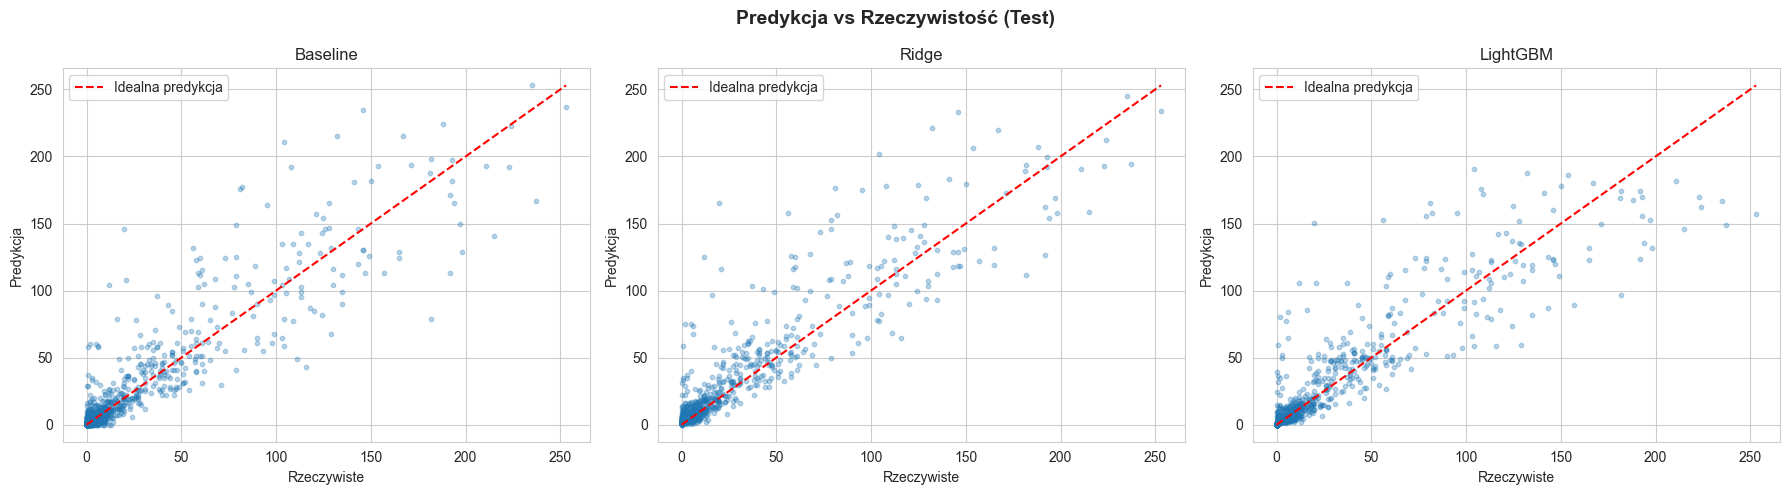

In [92]:
# ── Predykcja vs Rzeczywistość ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate([
    ('Baseline', X_test['lag_1']),
    ('Ridge', ridge_pred_test),
    ('LightGBM', lgb_pred_test)
]):
    axes[i].scatter(y_test, pred, alpha=0.3, s=10)
    max_val = max(y_test.max(), np.max(pred))
    axes[i].plot([0, max_val], [0, max_val], 'r--', label='Idealna predykcja')
    axes[i].set_xlabel('Rzeczywiste')
    axes[i].set_ylabel('Predykcja')
    axes[i].set_title(name)
    axes[i].legend()

plt.suptitle('Predykcja vs Rzeczywistość (Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


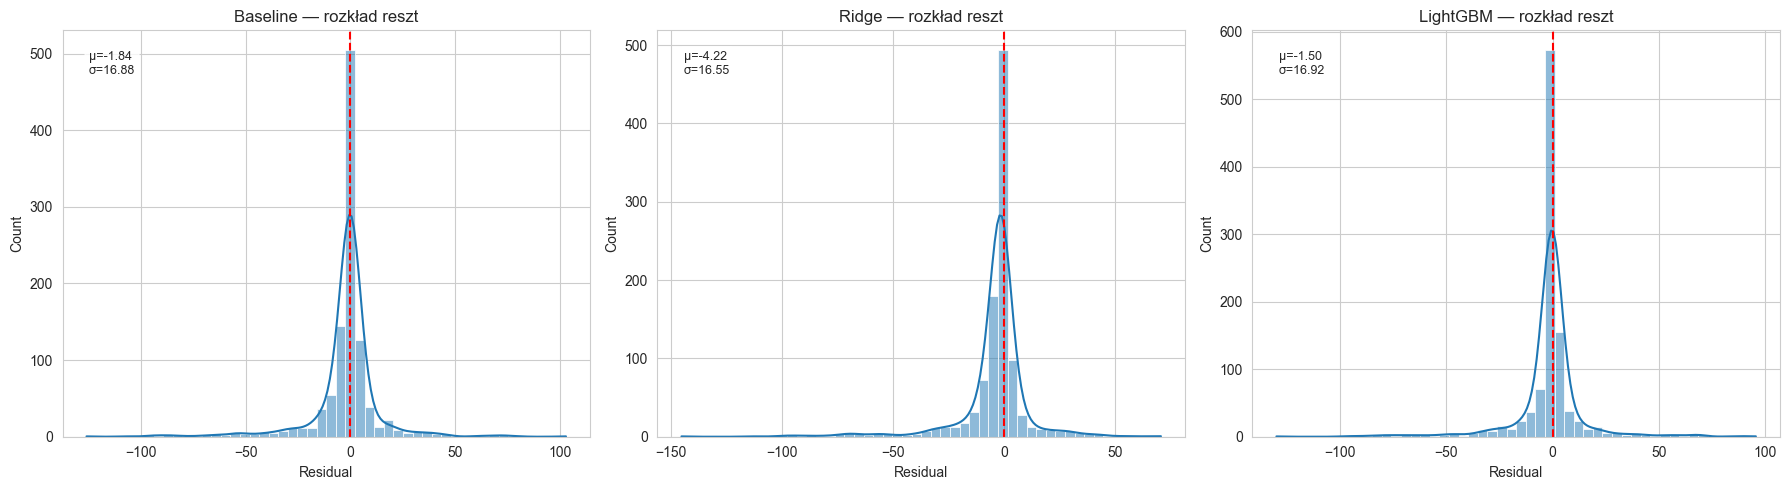

In [ ]:
# ── Rozkład reszt ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate([
    ('Baseline', np.array(X_test['lag_1'])),
    ('Ridge', ridge_pred_test),
    ('LightGBM', lgb_pred_test)
]):
    residuals = np.array(y_test) - np.array(pred)
    sns.histplot(residuals, bins=50, kde=True, ax=axes[i])
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_title(f'{name} — rozkład reszt')
    axes[i].set_xlabel('Residual')
    axes[i].text(0.05, 0.95, f'μ={residuals.mean():.2f}\nσ={residuals.std():.2f}',
                 transform=axes[i].transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


## 📦 ETAP 4: Trendy i stany magazynowe

📌 Analiza sprzedaży i wsparcie decyzji logistycznych

📈 Trendy sprzedaży w czasie  
🔁 Sezonowość  
🚨 Wykrywanie pików (np. Black Friday)  
📦 Estymacja zapotrzebowania / stock levels

## 🌐 ETAP 5: Aplikacja webowa

📌 Udostępnienie modelu i wyników w formie aplikacji

🧠 Integracja modelu  
📊 Dashboard (wykresy, metryki)  
⚡ API / Streamlit / Flask  
👤 Interakcja użytkownika